# MDTB Rest parcellations

In [1]:
from FusionModel.util import plot_data_flat, plot_multi_flat
from scripts.rest.fit import get_mdtb
import pickle
from IndividualParcellation.scripts.indiv_evaluation import make_eval_info, eval_parcel_DCBC
import scripts.rest.evaluation as ev
# Add the directories of necessary packages to the Python path
import numpy as np
import torch as pt
import nibabel as nb
import nitools as nt
import matplotlib.pyplot as plt
import Functional_Fusion.atlas_map as am
import Functional_Fusion.dataset as ds
import IndividualParcellation.scripts.paths as paths
from IndividualParcellation.scripts.paths import base_dir
import HierarchBayesParcel.arrangements as ar
import HierarchBayesParcel.full_model as fm
from FusionModel.util import plot_data_flat, plot_multi_flat
import pandas as pd
import seaborn as sb
import warnings
# Ignore RuntimeWarning
warnings.filterwarnings("ignore", category=RuntimeWarning)

pt.set_default_tensor_type(pt.cuda.FloatTensor
                           if pt.cuda.is_available() else
                           pt.FloatTensor)




/Users/callithrix/code/Python/IndividualParcellation/env/lib/python3.9/site-packages/torch/__init__.py:614: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/tensor/python_tensor.cpp:453.)
  _C._set_default_tensor_type(t)


In [2]:
# Settings
symmetric = True # Whether to get a symmetric or asymmetric parcellation
if symmetric:
    sym_type = 'sym'

space, _ = am.get_atlas('MNISymC2')
if space.name == 'MNISymC2':
    space_folder = 'tpl-MNI152NLin2009cSymC'

atlas_dir = paths.set_atlas_dir()
data_dir = paths.set_fusion_dir()
dataset_dir = data_dir + '/MDTB'
figure_dir = paths.set_figure_dir()

atlas = 'NettekovenSym32'
model_name = f'/{space_folder}/atl-{atlas}_space-{space_folder.split("tpl-")[1]}_probseg.nii'
_, cmap, labels = nt.read_lut(f'{atlas_dir}/{space_folder}/atl-{atlas}.lut')


In [3]:
v_types = {                    
                'general':               {'subject_specific_kappa':False, 'parcel_specific_kappa':False, 'subjects_equal_weight':False},
                'general_eq':            {'subject_specific_kappa':False, 'parcel_specific_kappa':False, 'subjects_equal_weight':True},
                'subject_specific':      {'subject_specific_kappa':True, 'parcel_specific_kappa':False, 'subjects_equal_weight':False},
                'subject_specific_eq':   {'subject_specific_kappa':True, 'parcel_specific_kappa':False, 'subjects_equal_weight':True},
                }

vmodel_types = {
            'general':               {'subject_specific_kappa':False, 'parcel_specific_kappa':False, 'subjects_equal_weight':False},
            'subject_specific':      {'subject_specific_kappa':True, 'parcel_specific_kappa':False, 'subjects_equal_weight':False},
            }

base_dir = paths.set_base_dir()
results_dir = paths.set_results_dir(base_dir)
mdtb_Vmodels = {f'{mtype}_{vtype}': pickle.load(open(f'{results_dir}/fitted_emissions/fitted_rest-mdtb_mtype-{mtype}_vtype-{vtype}.pkl', 'rb')) for mtype in vmodel_types.keys() for vtype in v_types.keys()}
# Fusion 06 models fitted with HCP Vs
mdtb_Vmodels_fus = {f'{mtype}_{vtype}': pickle.load(open(f'{results_dir}/fitted_emissions/fitted_rest-mdtb_dtype-Fus06Run_mtype-{mtype}_vtype-{vtype}.pkl', 'rb')) for mtype in vmodel_types.keys() for vtype in v_types.keys()}



In [25]:
mdtb_Vmodels_fus = {f'{mtype}_{vtype}': pickle.load(open(f'{results_dir}/fitted_emissions/fitted_rest-mdtb_dtype-Fus06Run_mtype-{mtype}_vtype-{vtype}.pkl', 'rb')) for mtype in vmodel_types.keys() for vtype in v_types.keys()}


In [4]:
T = pd.read_csv(
    base_dir + '/FunctionalFusion/MDTB/participants.tsv', delimiter='\t')
mdtb_rest_subjects = T.participant_id[T['ses-rest'] == 1].tolist()

In [77]:
# Get Uhat
Uhats = {}
for model_type in mdtb_Vmodels.keys():
    selected_vmodel = mdtb_Vmodels[model_type]
    emloglik_c = [e.Estep() for e in selected_vmodel.emissions]
    emloglik_comb = selected_vmodel.collect_evidence(emloglik_c)  # Combine subjects
    Uhat, ll_A = selected_vmodel.arrange.Estep(emloglik_comb)
    Uhats[model_type] = Uhat


In [26]:
# Get Uhats for Fusion 06 model
Uhats_fus = {}
for model_type in mdtb_Vmodels_fus.keys():
    selected_vmodel = mdtb_Vmodels_fus[model_type]
    emloglik_c = [e.Estep() for e in selected_vmodel.emissions]
    emloglik_comb = selected_vmodel.collect_evidence(emloglik_c)  # Combine subjects
    Uhat_fus, ll_A = selected_vmodel.arrange.Estep(emloglik_comb)
    Uhats_fus[model_type] = Uhat_fus


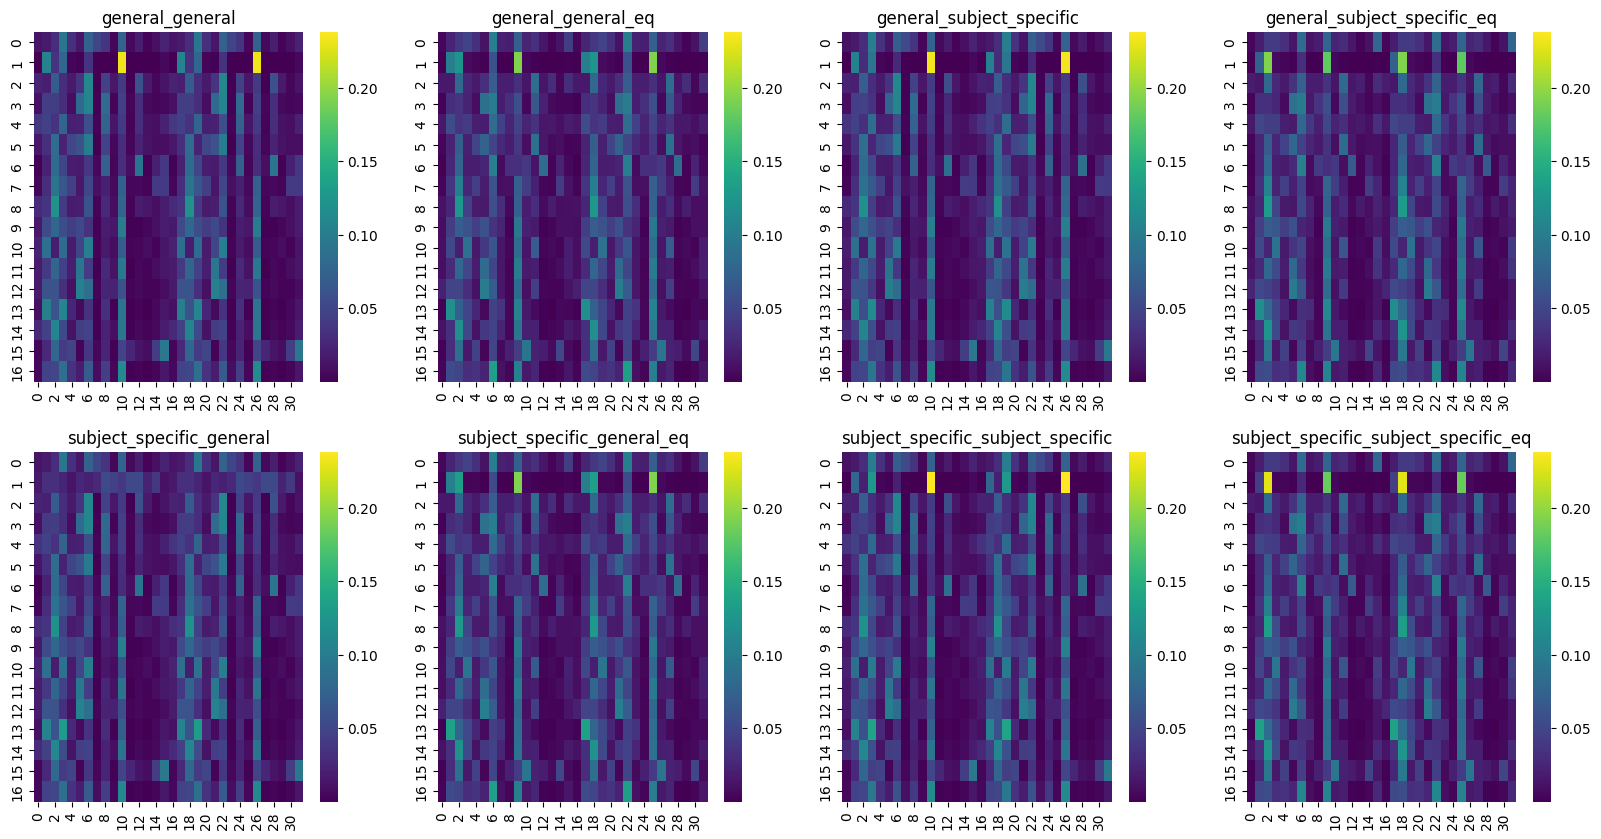

In [78]:
#Get max of Uhats
max_Uhat = np.max([np.nanmean(Uhats[model_type].numpy(), axis=2) for model_type in Uhats.keys()])
min_Uhat = np.min([np.nanmean(Uhats[model_type].numpy(), axis=2) for model_type in Uhats.keys()])

fig, axs = plt.subplots(2, 4, figsize=(20, 10))
for i, model_type in enumerate(Uhats.keys()):
    Uhat = np.nanmean(Uhats[model_type].numpy(), axis=2)
    sb.heatmap(Uhat, cmap='viridis', ax=axs[i // 4, i % 4], vmin=min_Uhat, vmax=max_Uhat)
    axs[i // 4, i % 4].set_title(model_type)
    
    

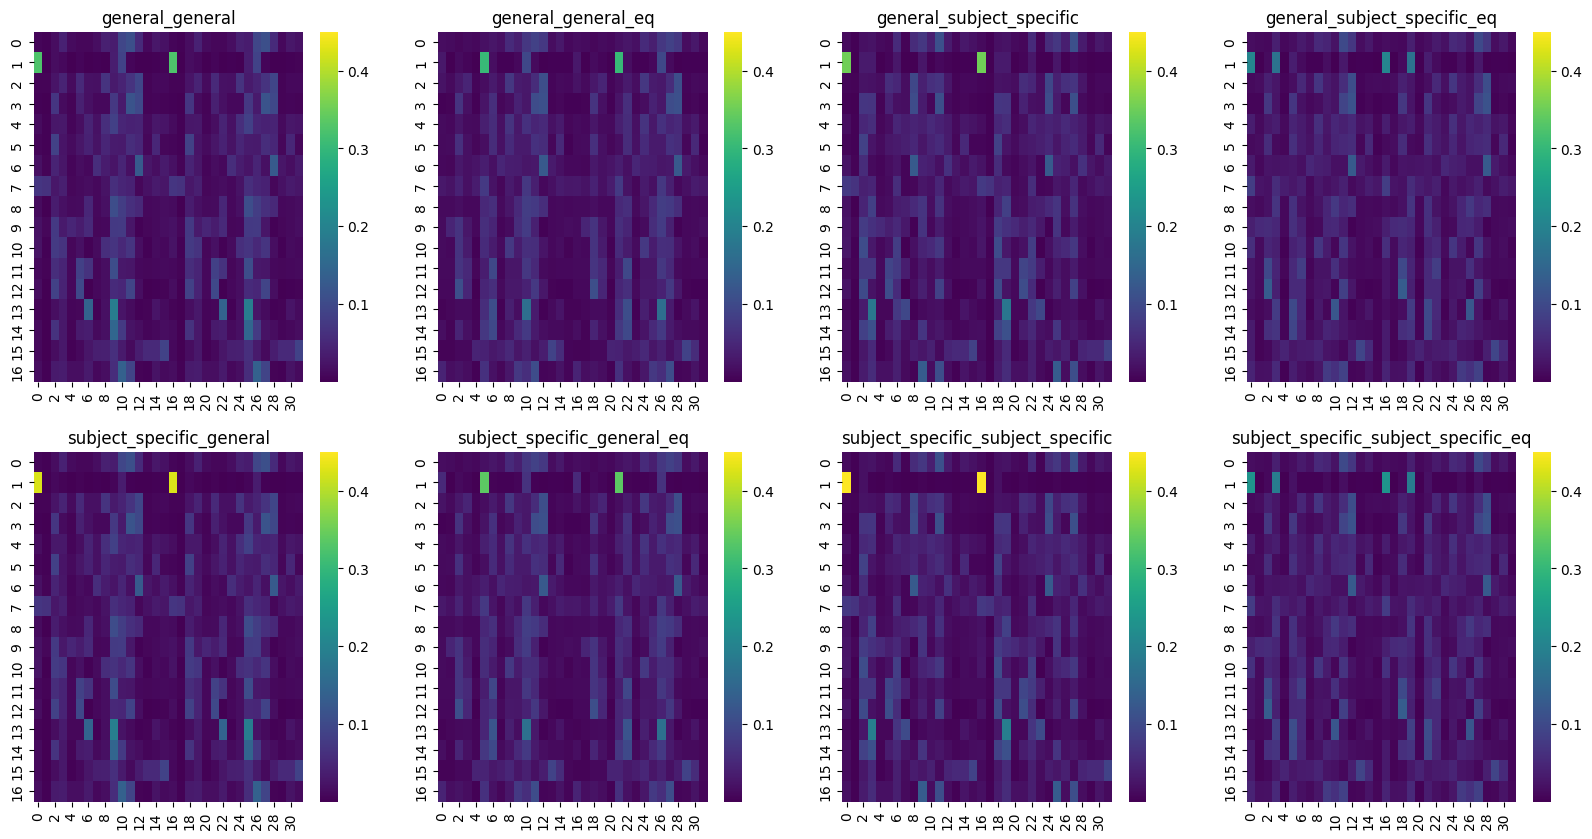

In [29]:
#Get max of Uhats_fus fitted with HCP Vs
max_Uhats_fus = np.max([np.nanmean(Uhats_fus[model_type].numpy(), axis=2) for model_type in Uhats_fus.keys()])
min_Uhats_fus = np.min([np.nanmean(Uhats_fus[model_type].numpy(), axis=2) for model_type in Uhats_fus.keys()])

fig, axs = plt.subplots(2, 4, figsize=(20, 10))
for i, model_type in enumerate(Uhats_fus.keys()):
    Uhat_fus = np.nanmean(Uhats_fus[model_type].numpy(), axis=2)
    sb.heatmap(Uhat_fus, cmap='viridis', ax=axs[i // 4, i % 4], vmin=min_Uhats_fus, vmax=max_Uhats_fus)
    axs[i // 4, i % 4].set_title(model_type)
    
    

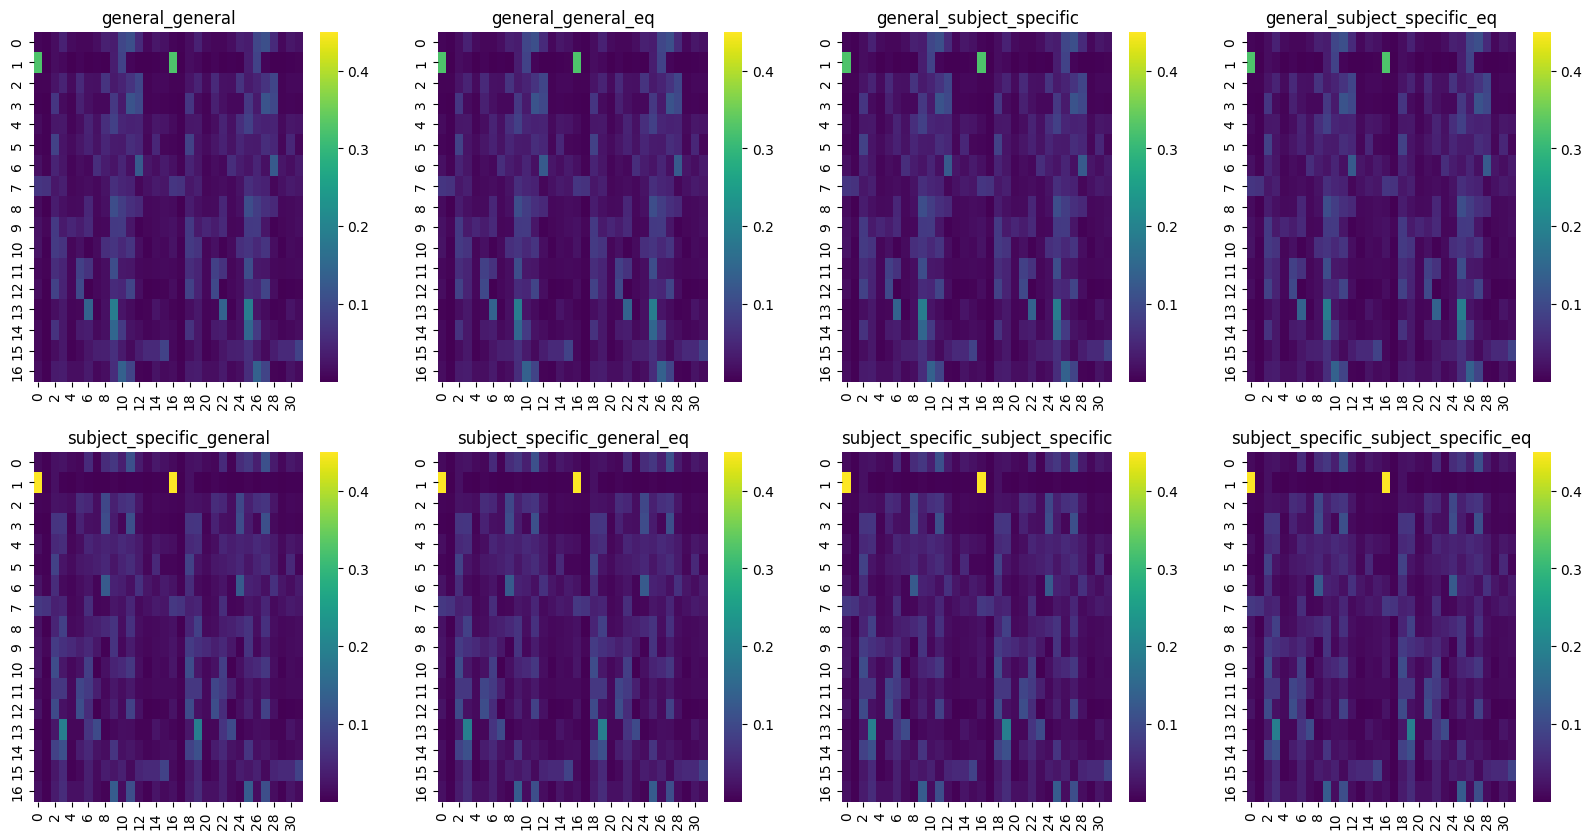

In [18]:
#Get max of Uhats_fus fitted without HCP Vs
max_Uhats_fus = np.max([np.nanmean(Uhats_fus[model_type].numpy(), axis=2) for model_type in Uhats_fus.keys()])
min_Uhats_fus = np.min([np.nanmean(Uhats_fus[model_type].numpy(), axis=2) for model_type in Uhats_fus.keys()])

fig, axs = plt.subplots(2, 4, figsize=(20, 10))
for i, model_type in enumerate(Uhats_fus.keys()):
    Uhat_fus = np.nanmean(Uhats_fus[model_type].numpy(), axis=2)
    sb.heatmap(Uhat_fus, cmap='viridis', ax=axs[i // 4, i % 4], vmin=min_Uhats_fus, vmax=max_Uhats_fus)
    axs[i // 4, i % 4].set_title(model_type)
    
    

torch.Size([17, 32, 18290])

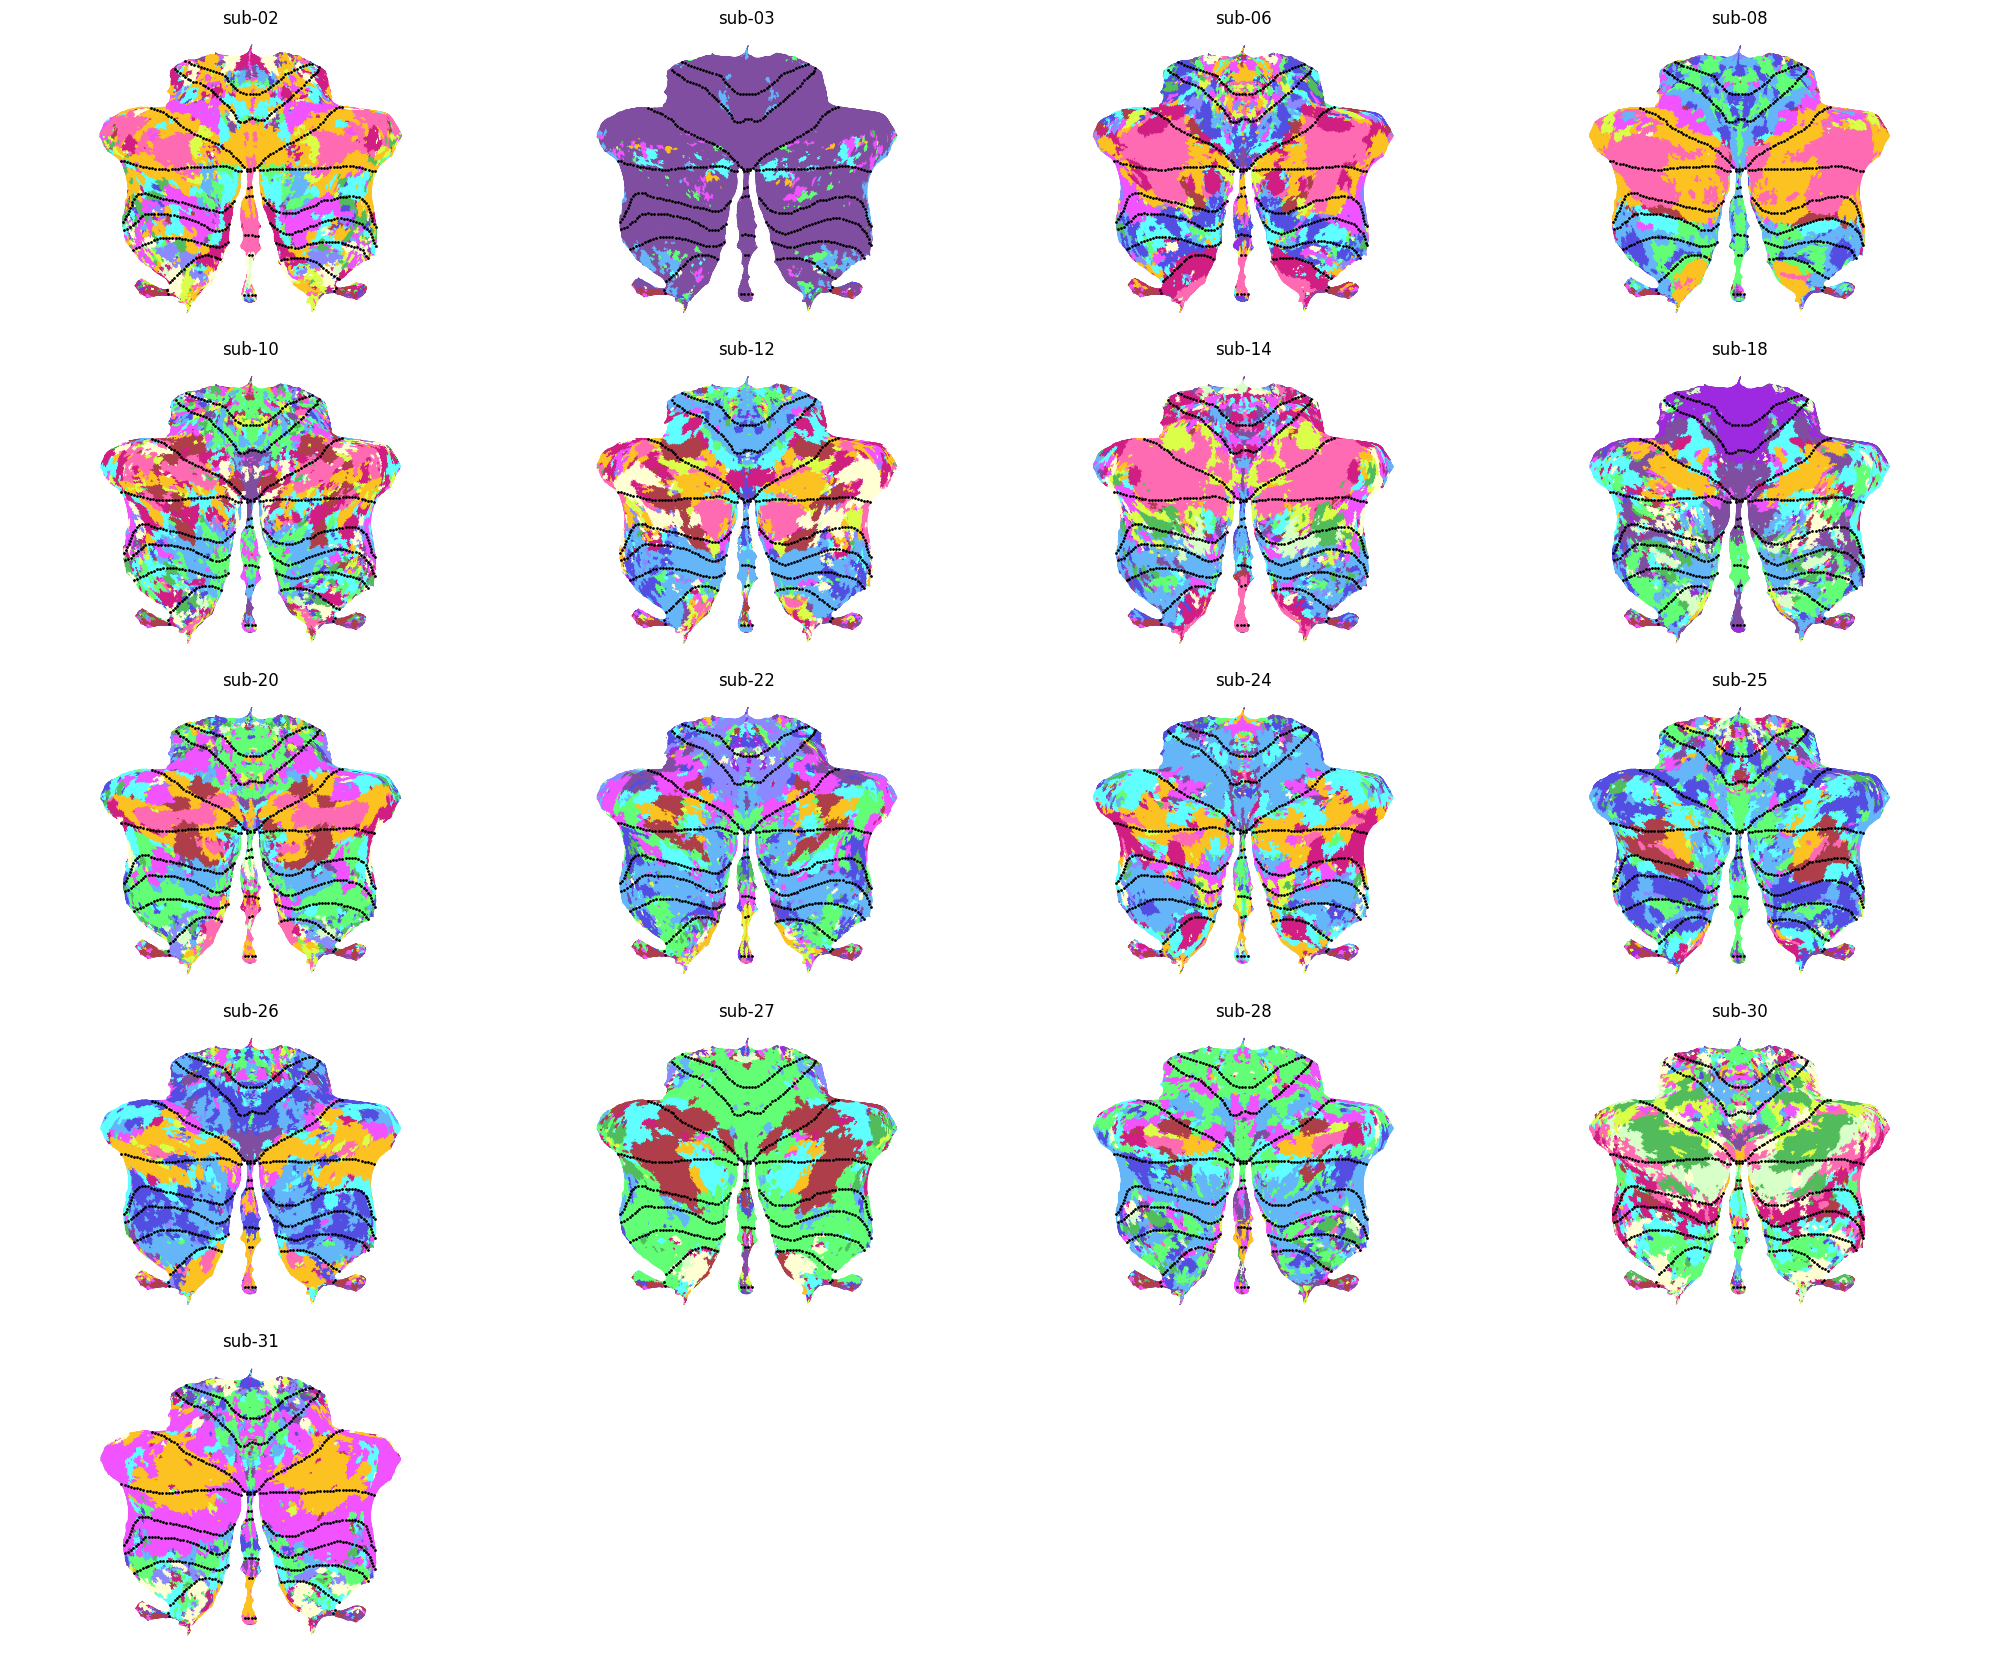

In [31]:
plt.figure(figsize=(20,20))
plot_multi_flat(Uhats_fus['general_subject_specific'].numpy(), atlas=space.name, grid=(6, 4),
                titles = mdtb_rest_subjects,
                cmap=cmap, dtype='prob')


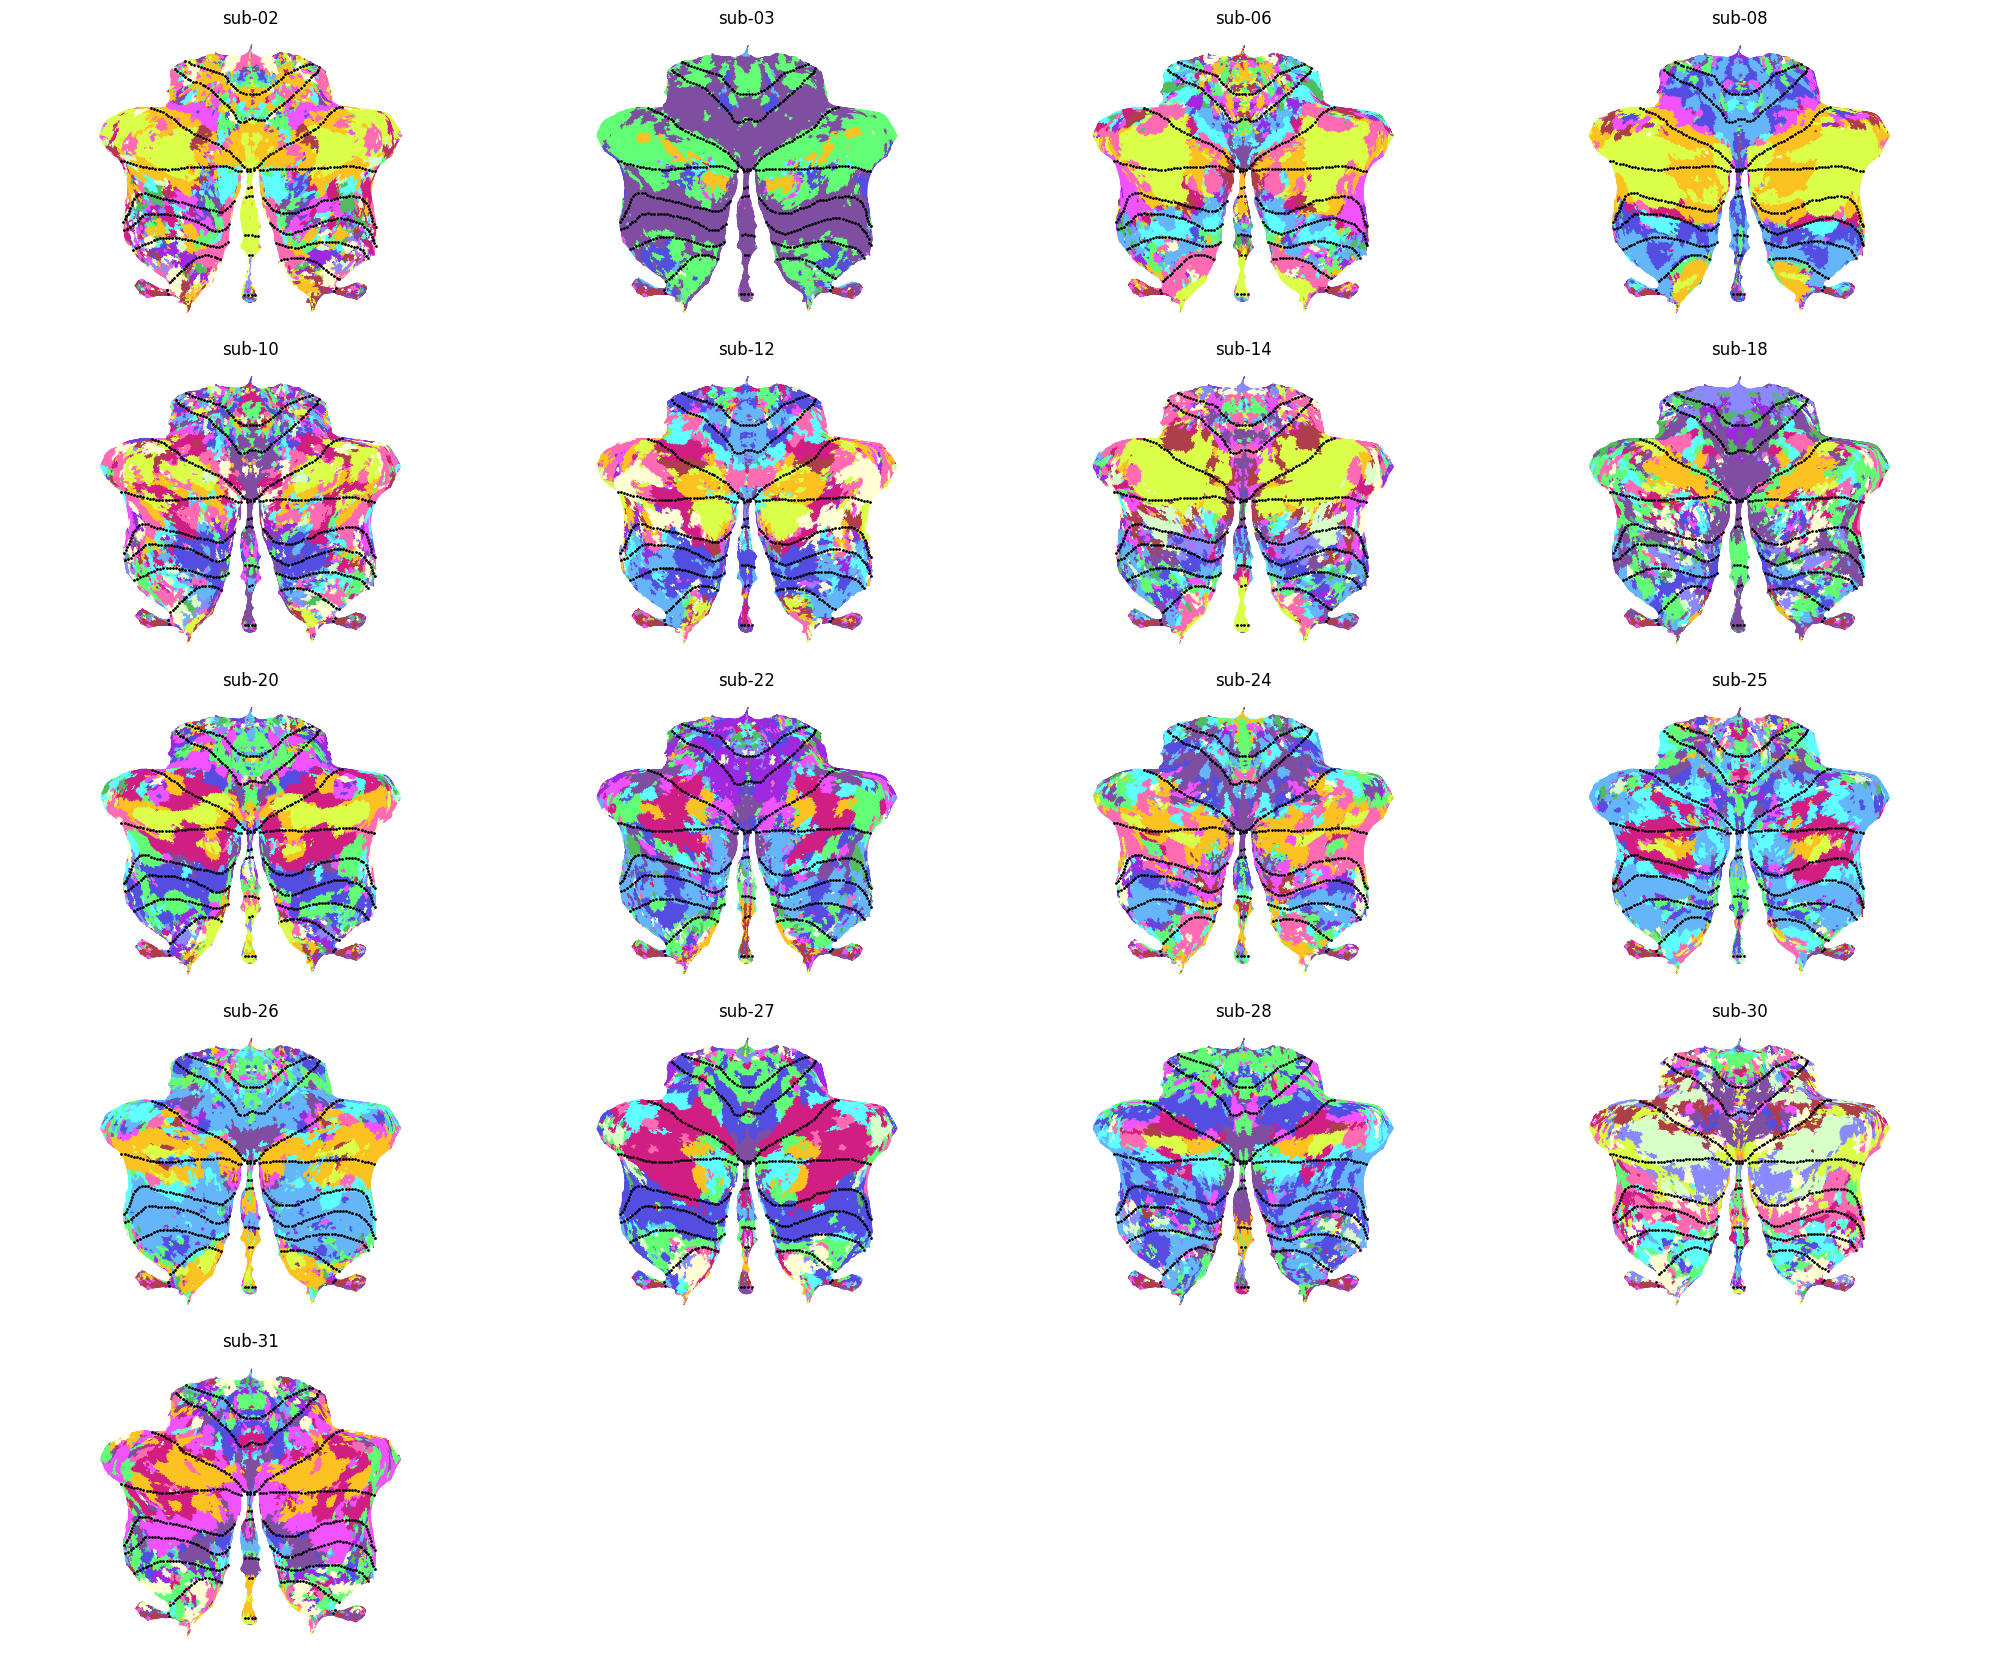

In [30]:
plt.figure(figsize=(20,20))
plot_multi_flat(Uhats_fus['general_subject_specific_eq'].numpy(), atlas=space.name, grid=(6, 4),
                titles = mdtb_rest_subjects,
                cmap=cmap, dtype='prob')


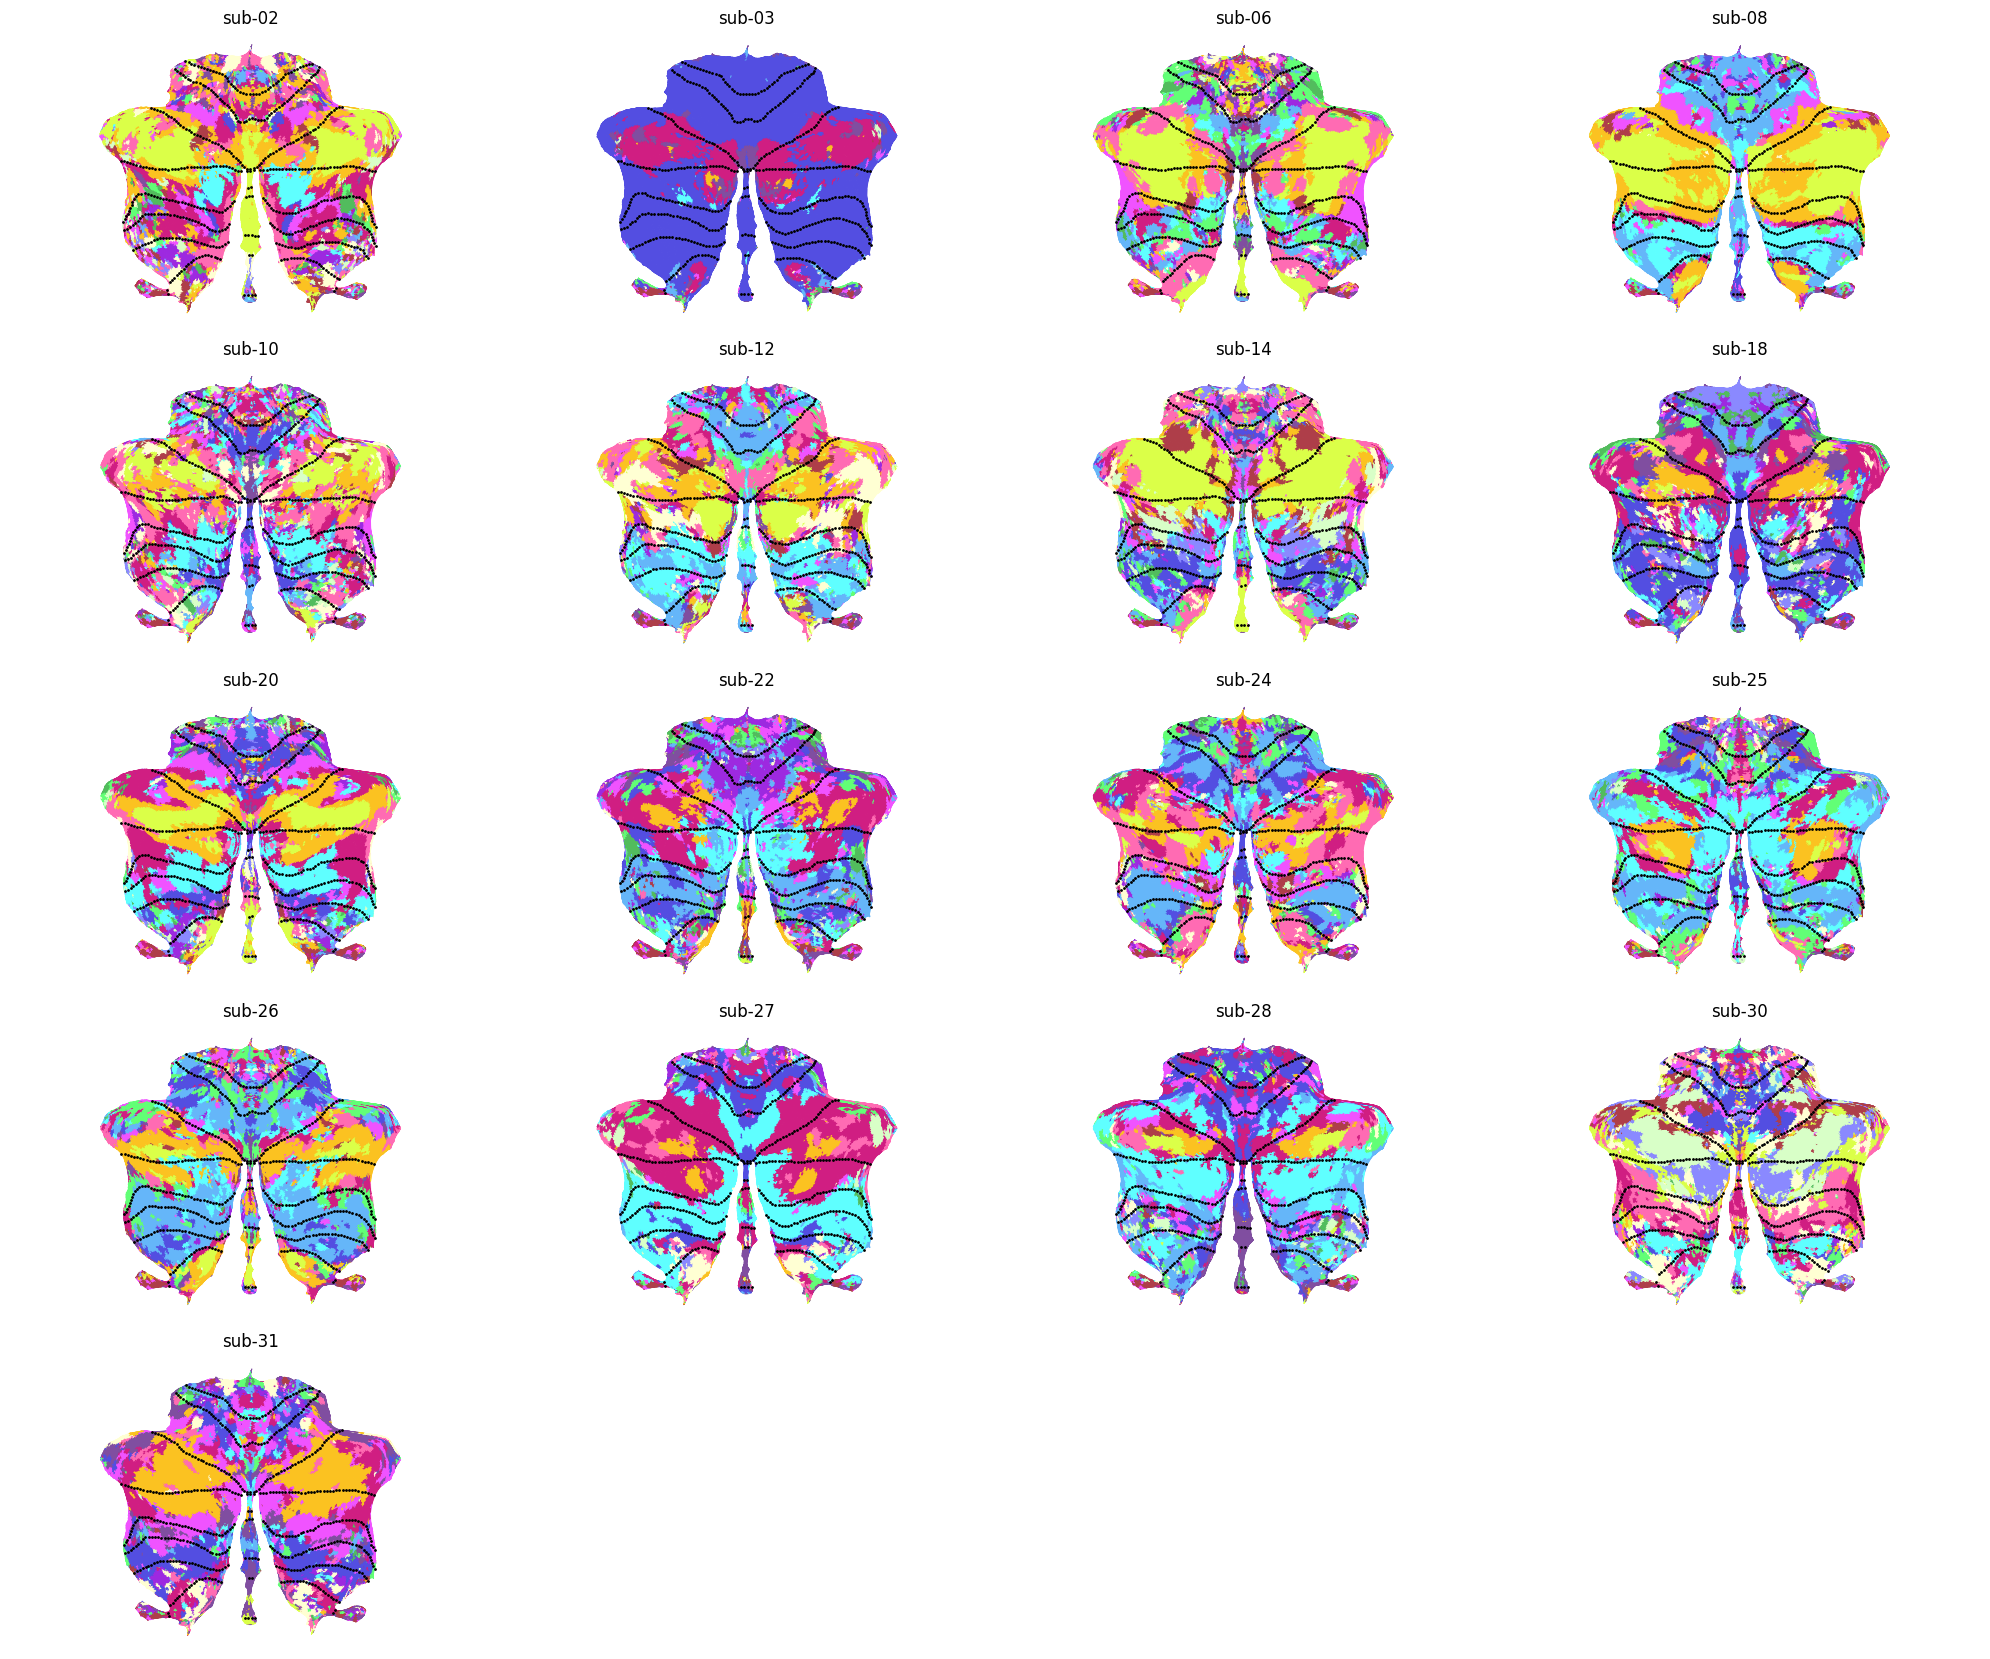

In [28]:
plt.figure(figsize=(20,20))
plot_multi_flat(Uhats_fus['general_general_eq'].numpy(), atlas=space.name, grid=(6, 4),
                titles = mdtb_rest_subjects,
                cmap=cmap, dtype='prob')


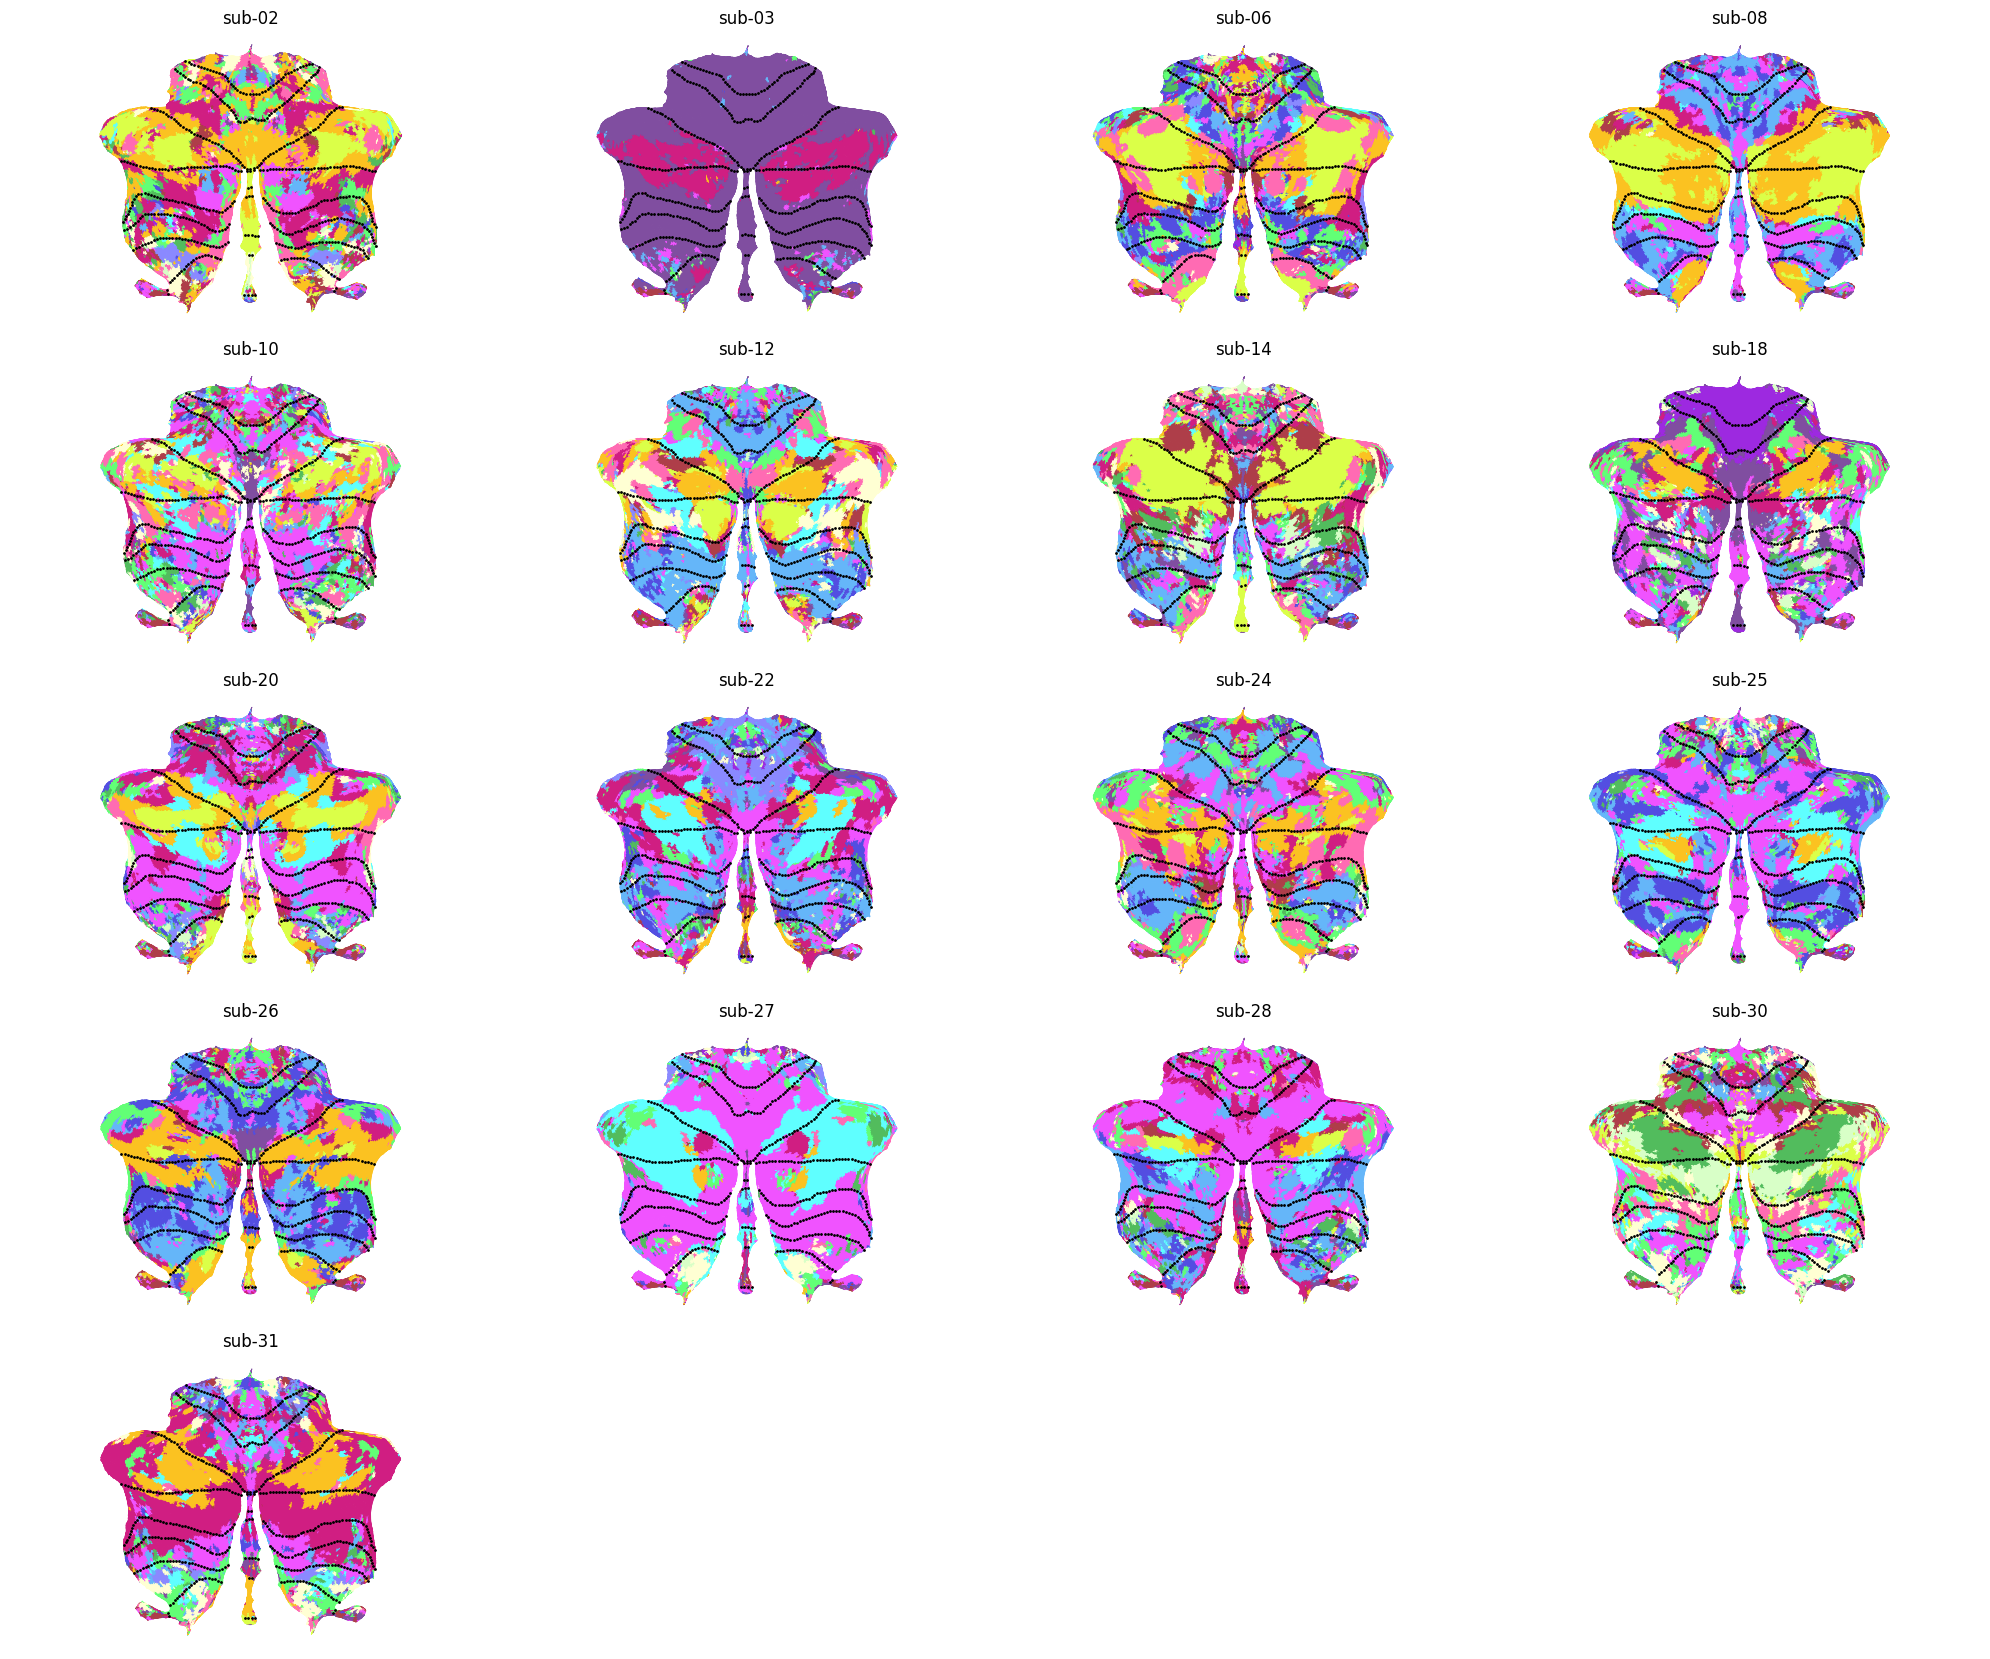

In [24]:
plt.figure(figsize=(20,20))
plot_multi_flat(Uhats_fus['general_general_eq'].numpy(), atlas=space.name, grid=(6, 4),
                titles = mdtb_rest_subjects,
                cmap=cmap, dtype='prob')


# Show HCP parcellation distribution

In [45]:
hcp_models = {mtype: pickle.load(open(f'{results_dir}/fitted_emissions/fitted_rest-hcp_mtype-{mtype}.pkl', 'rb')) for mtype in v_types.keys()}

In [46]:
# Get Uhat from HCP
Uhats_hcp = {}
for model_type in v_types.keys():
    selected_vmodel = hcp_models[model_type]
    emloglik_c = [e.Estep() for e in selected_vmodel.emissions]
    emloglik_comb = selected_vmodel.collect_evidence(emloglik_c)  # Combine subjects
    Uhat, ll_A = selected_vmodel.arrange.Estep(emloglik_comb)
    Uhats_hcp[model_type] = Uhat


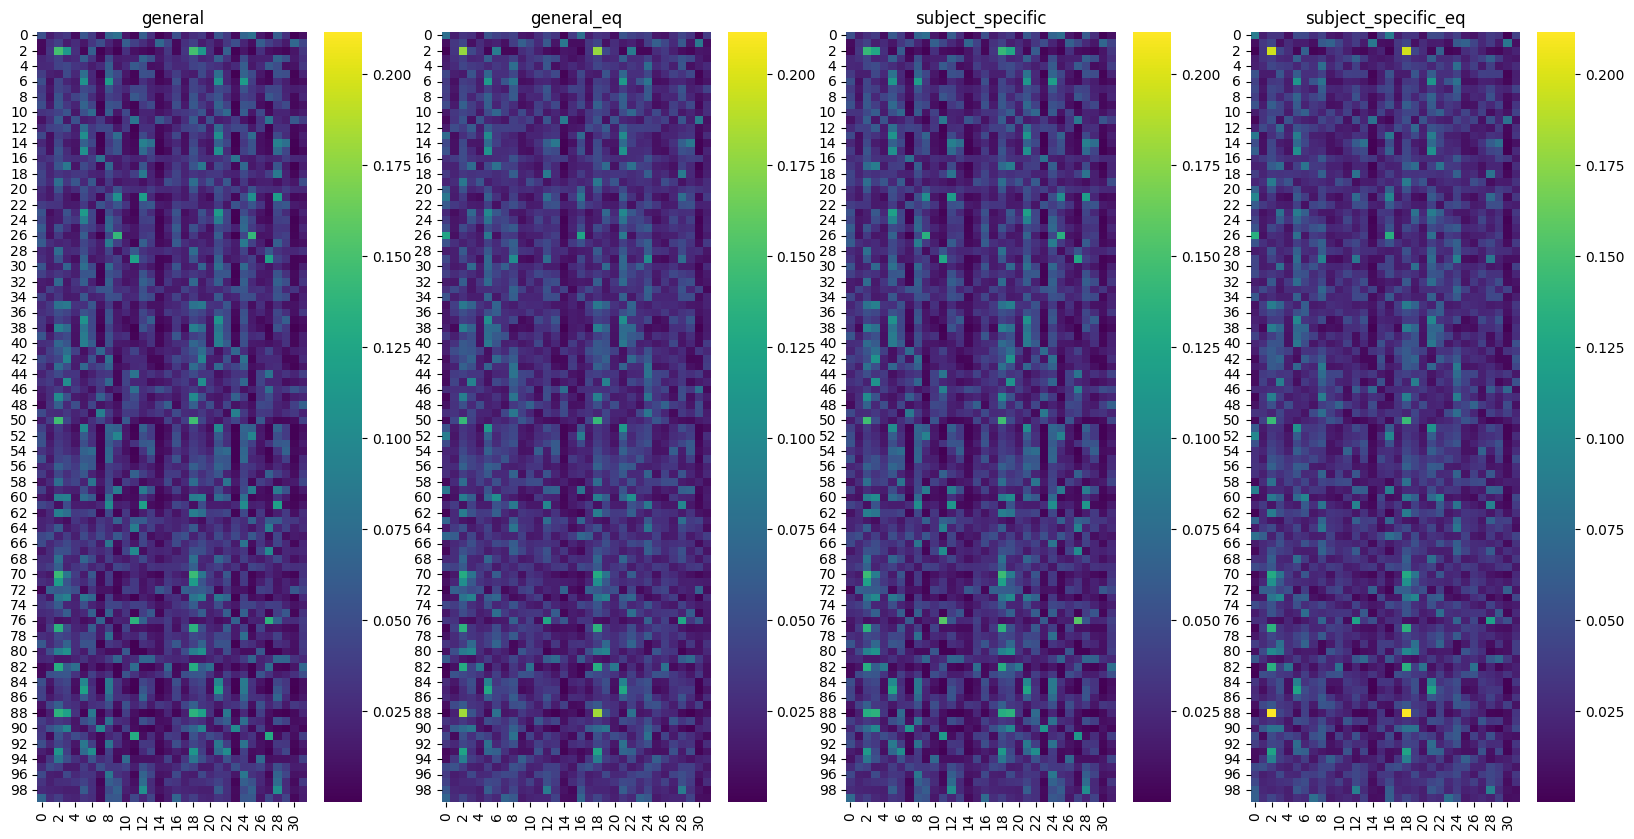

In [50]:
#Get max of Uhats
max_Uhat = np.max([np.nanmean(Uhats_hcp[model_type].numpy(), axis=2) for model_type in Uhats_hcp.keys()])
min_Uhat = np.min([np.nanmean(Uhats_hcp[model_type].numpy(), axis=2) for model_type in Uhats_hcp.keys()])

fig, axs = plt.subplots(1, 4, figsize=(20, 10))
for i, model_type in enumerate(Uhats_hcp.keys()):
    Uhat = np.nanmean(Uhats_hcp[model_type].numpy(), axis=2)
    sb.heatmap(Uhat, cmap='viridis', ax=axs[i], vmin=min_Uhat, vmax=max_Uhat)
    axs[i].set_title(model_type)
    
    

# Evaluate parcellations

In [11]:
# Load MDTB task data
data, info, tds = ds.get_dataset(data_dir, 'MDTB', atlas=space.name, subj=mdtb_rest_subjects)
tdata, cond_v, part_v, sub_ind = fm.prep_datasets(data, info.sess,
                                                    info['cond_num_uni'].values,
                                                    info['half'].values,
                                                    join_sess=False,
                                                    join_sess_part=False)

In [12]:
# -- Evaluate the individual parcellations --
# Load MDTB session sc2 to evaluate
dist = ev.compute_dist(space.world.T, resolution=1)

In [15]:
# Make evaluation info
# model_name = f'/Models_03/NettekovenSym32_space-MNISymC2'
# model_dir = paths.set_model_dir()
# _, minfo = ar.load_group_parcellation(model_dir + model_name, device=DEVICE)
eval_info = make_eval_info(mdtb_Vmodels['general_general'], tdata='MDTB', group_type='Models_03',
                            indivtrain_ind='half', indivtrain_values=1,
                            indivtest_values=2, test_kappa=None)

In [16]:
U.shape

(32, 18290)

In [17]:

mtype = 'general_general'
ev_task = eval_parcel_DCBC(U, Uhats[mtype], tdata[1], dist, eval_info,
                    out_file=f'eval_dcbc_{mtype}.tsv')
# ev_task['type'] = ['task']*ev_task.shape[0]
# ev_rest = eval_parcel_DCBC(U, indiv_par_rest_net67, tdata[1], dist, eval_info,
#                     out_file='eval_dcbc_indiv_parcellations_rest.tsv')
# ev_rest['type'] = ['rest']*ev_task.shape[0]
# ev_rest_vs = eval_parcel_DCBC(U, indiv_par_rest_net67_vs, tdata[1], dist, eval_info,
#                     out_file='eval_dcbc_indiv_parcellations_rest_vs.tsv')
# ev_rest_vs['type'] = ['rest_Vs']*ev_task.shape[0]

# # Concate the results
# ev_df = pd.concat([ev_task, ev_rest, ev_rest_vs], axis=0)
# ev_df.to_csv('eval_dcbc_indiv_parcellations_all.tsv', sep='\t')

NameError: name 'calc_test_dcbc' is not defined